In [ ]:
import pandas as pd
import os
import pyodbc
from dotenv import load_dotenv
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose

load_dotenv()

server = os.getenv("DB_SERVER")
database = os.getenv("DB_DATABASE")

connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

def get_connection():
    return pyodbc.connect(connection_string)


In [16]:

query = """
SELECT
    product_id,
    SUM(quantity * price) AS total_sales
FROM invoice_items
GROUP BY product_id
ORDER BY total_sales DESC;
"""

db_total_sales = pd.read_sql(query, get_connection())

print(db_total_sales.head(20))

C:\Users\rar95\AppData\Local\Temp\ipykernel_4680\806702938.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  db_total_sales = pd.read_sql(query, get_connection())


    product_id  total_sales
0         2414    168469.60
1         2876    142592.95
2         3851    100448.15
3         1828     85220.78
4         2074     81416.73
5         2711     77803.96
6         2439     68844.33
7          209     56580.34
8         2061     53779.93
9         2762     51346.20
10         738     46286.51
11        2408     42660.83
12        2494     39619.50
13         374     39064.55
14        1826     37289.59
15        1054     35913.85
16        3461     35539.25
17        3901     34478.01
18        3122     33347.80
19        1795     32662.97


In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
customers = pd.read_csv(r"D:\All ML Projects\Retail_Demand_Forecasting\data\raw\customers.csv")
invoice_items = pd.read_csv(r"D:\All ML Projects\Retail_Demand_Forecasting\data\raw\invoice_items.csv")
products = pd.read_csv(r"D:\All ML Projects\Retail_Demand_Forecasting\data\raw\products.csv")
purchases = pd.read_csv(r"D:\All ML Projects\Retail_Demand_Forecasting\data\raw\purchases.csv")

In [21]:
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Purchases:", purchases.shape)
print("Invoice Items:", invoice_items.shape)

Customers: (8237, 2)
Products: (4033, 4)
Purchases: (436689, 5)
Invoice Items: (436689, 5)


In [22]:
print("\nCustomers:")
print(customers.columns.tolist())

print("\nProducts:")
print(products.columns.tolist())

print("\nPurchases:")
print(purchases.columns.tolist())

print("\nInvoice Items:")
print(invoice_items.columns.tolist())


Customers:
['CustomerID', 'customer_type']

Products:
['product_id', 'item', 'category', 'price']

Purchases:
['InvoiceID', 'date', 'CustomerID', 'product_id', 'quantity']

Invoice Items:
['InvoiceID', 'product_id', 'quantity', 'price', 'line_total']


In [23]:
display(customers.head())
display(products.head())
display(purchases.head())
display(invoice_items.head())

,CustomerID,customer_type
0,17850,wholesaler
1,13047,wholesaler
2,12583,wholesaler
3,13748,private
4,15100,private


,product_id,item,category,price
0,3851,white hanging heart t-light holder,Home Decor,2.55
1,3859,white metal lantern,Home Decor,3.39
2,885,cream cupid hearts coat hanger,"Health, Beauty & Personal Care",2.75
3,1873,knitted union flag hot water bottle,Party & Festive,3.39
4,2871,red woolly hottie white heart.,"Health, Beauty & Personal Care",3.39


,InvoiceID,date,CustomerID,product_id,quantity
0,536365,2014-12-01,17850,3851,6
1,536365,2014-12-01,17850,3859,6
2,536365,2014-12-01,17850,885,8
3,536365,2014-12-01,17850,1873,6
4,536365,2014-12-01,17850,2871,6


,InvoiceID,product_id,quantity,price,line_total
0,536365,3851,6,2.55,15.30
1,536365,3859,6,3.39,20.34
2,536365,885,8,2.75,22.00
3,536365,1873,6,3.39,20.34
4,536365,2871,6,3.39,20.34


In [27]:
# Check data types
print(purchases.dtypes)
print()
print(products.dtypes)
print()
print(invoice_items.dtypes)

InvoiceID              int64
date          datetime64[ns]
CustomerID             int64
product_id             int64
quantity               int64
dtype: object

product_id      int64
item           object
category       object
price         float64
dtype: object

InvoiceID       int64
product_id      int64
quantity        int64
price         float64
line_total    float64
dtype: object


In [26]:
# Convert date column to datetime
purchases["date"] = pd.to_datetime(purchases["date"])


In [28]:
# Basic statistics for numerical columns

print("Purchases numerical statistics:")
display(purchases.describe())

print("Products numerical statistics:")
display(products.describe())

print("Invoice Items numerical statistics:")
display(invoice_items.describe())


Purchases numerical statistics:


,InvoiceID,date,CustomerID,product_id,quantity
count,436689.000000,436689,436689.000000,436689.000000,436689.000000
mean,511514.110834,2015-06-24 07:26:07.065806336,14203.268795,2109.265131,12.087628
min,1.000000,2014-01-01 00:00:00,1000.000000,1.000000,1.000000
25%,545589.000000,2015-03-23 00:00:00,13384.000000,1171.000000,2.000000
50%,559545.000000,2015-07-19 00:00:00,14911.000000,2093.000000,4.000000
75%,571229.000000,2015-10-17 00:00:00,16705.000000,3062.000000,12.000000
max,581587.000000,2015-12-30 00:00:00,18287.000000,4033.000000,80995.000000
std,157823.706391,NaN,3874.517869,1137.512313,172.252472


Products numerical statistics:


,product_id,price
count,4033.000000,4033.000000
mean,2017.000000,3.798143
std,1164.371146,13.059295
min,1.000000,0.001000
25%,1009.000000,1.250000
50%,2017.000000,2.100000
75%,3025.000000,4.150000
max,4033.000000,649.500000


Invoice Items numerical statistics:


,InvoiceID,product_id,quantity,price,line_total
count,436689.000000,436689.000000,436689.000000,436689.00000,436689.000000
mean,511514.110834,2109.265131,12.087628,3.22677,21.374055
std,157823.706391,1137.512313,172.252472,21.11145,295.049213
min,1.000000,1.000000,1.000000,0.00000,0.000000
25%,545589.000000,1171.000000,2.000000,1.25000,4.680000
50%,559545.000000,2093.000000,4.000000,2.08000,10.760000
75%,571229.000000,3062.000000,12.000000,3.75000,18.990000
max,581587.000000,4033.000000,80995.000000,8142.75000,168469.600000


In [29]:
# Check date range

print("Minimum date:", purchases["date"].min())
print("Maximum date:", purchases["date"].max())
print("Number of unique dates:", purchases["date"].nunique())

Minimum date: 2014-01-01 00:00:00
Maximum date: 2015-12-30 00:00:00
Number of unique dates: 728


In [32]:
daily_demand = (
    purchases
    .groupby("date")["quantity"]
    .sum()
    .reset_index()
)

daily_demand.head()

,date,quantity
0,2014-01-01,131
1,2014-01-02,140
2,2014-01-03,117
3,2014-01-04,98
4,2014-01-05,153


In [48]:
daily_demand = (
    purchases.groupby("date")["quantity"]
    .sum()
    .reset_index()
)

print(daily_demand.columns)
display(daily_demand.head())

Index(['date', 'quantity'], dtype='object')


,date,quantity
0,2014-01-01,131
1,2014-01-02,140
2,2014-01-03,117
3,2014-01-04,98
4,2014-01-05,153


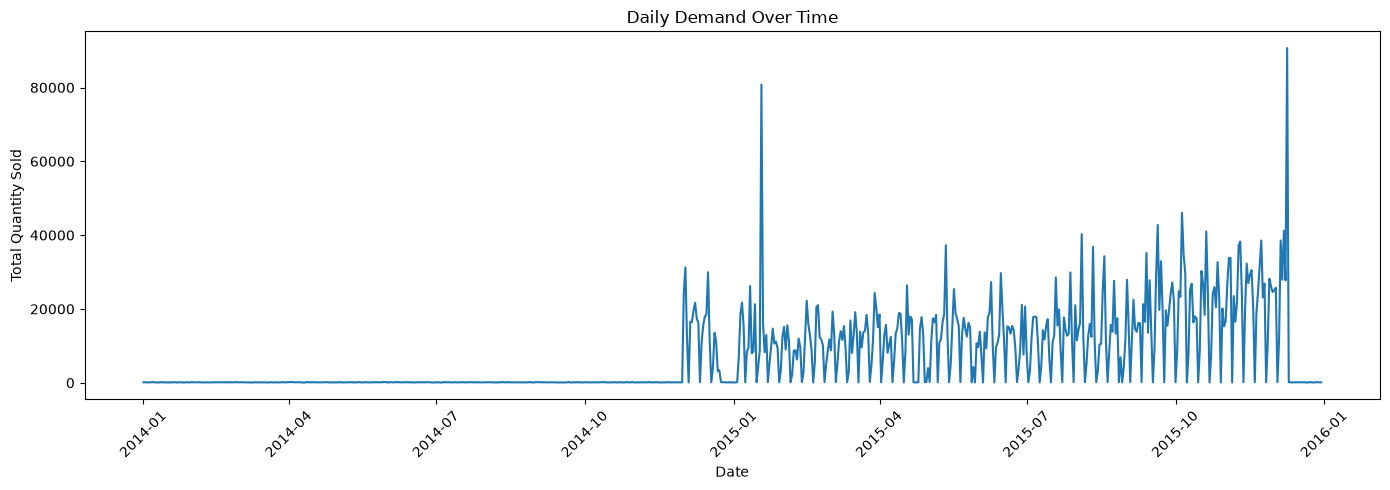

In [49]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_demand["date"],
    daily_demand["quantity"]
)

plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.title("Daily Demand Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
monthly_demand = (
    purchases
    .groupby(purchases["date"].dt.to_period("M"))["quantity"]
    .sum()
    .reset_index()
)

monthly_demand.columns = ["month", "quantity"]

display(monthly_demand)

,month,quantity
0,2014-01,3794
1,2014-02,3533
2,2014-03,3557
3,2014-04,3859
4,2014-05,4073
5,2014-06,3947
6,2014-07,3900
7,2014-08,3882
8,2014-09,3668
9,2014-10,3889


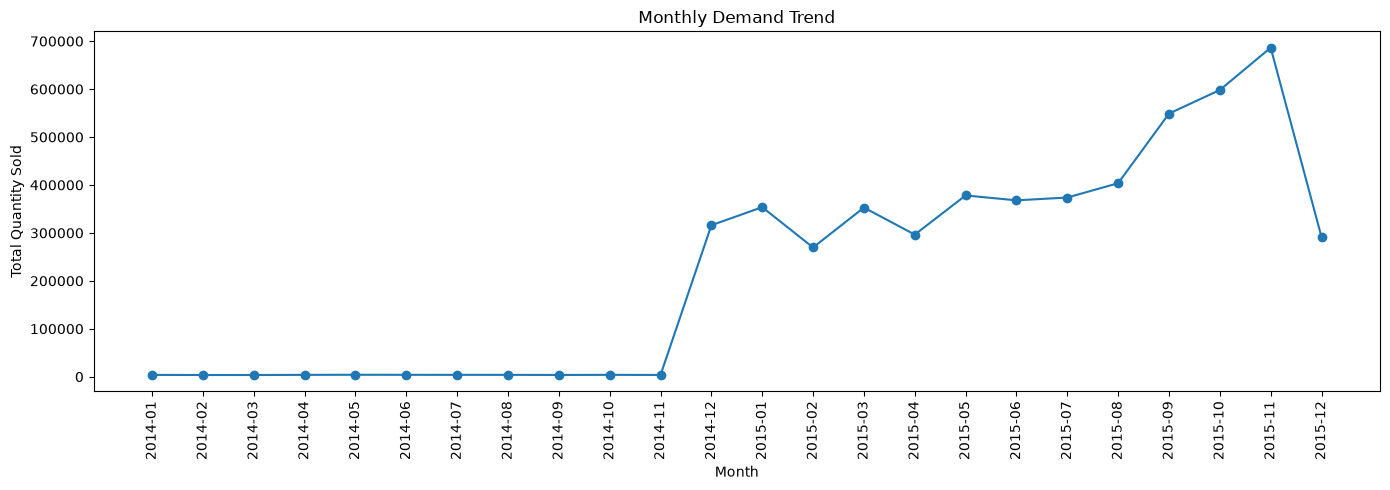

In [52]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_demand["month"].astype(str),
    monthly_demand["quantity"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.title("Monthly Demand Trend")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [53]:
monthly_analysis = (
    purchases
    .groupby(purchases["date"].dt.to_period("M"))
    .agg(
        purchase_rows=("InvoiceID", "size"),
        unique_invoices=("InvoiceID", "nunique"),
        unique_customers=("CustomerID", "nunique"),
        total_quantity=("quantity", "sum")
    )
    .reset_index()
)

monthly_analysis.columns = [
    "month",
    "purchase_rows",
    "unique_invoices",
    "unique_customers",
    "total_quantity"
]

display(monthly_analysis)

,month,purchase_rows,unique_invoices,unique_customers,total_quantity
0,2014-01,1527,665,612,3794
1,2014-02,1437,623,589,3533
2,2014-03,1411,608,573,3557
3,2014-04,1561,678,632,3859
4,2014-05,1615,711,660,4073
5,2014-06,1570,674,613,3947
6,2014-07,1576,680,628,3900
7,2014-08,1575,690,637,3882
8,2014-09,1472,651,602,3668
9,2014-10,1591,697,639,3889


In [42]:
monthly_analysis[
    monthly_analysis["month"].isin(
        [pd.Period("2014-11"),
         pd.Period("2014-12"),
         pd.Period("2015-01")]
    )
]

,month,purchase_rows,unique_invoices,unique_customers,total_quantity
10,2014-11,1469,647,608,3674
11,2014-12,27633,2057,1487,315998
12,2015-01,23029,1609,1321,353660


In [54]:
monthly_quantity_analysis = (
    purchases
    .groupby(purchases["date"].dt.to_period("M"))
    .agg(
        avg_quantity_per_row=("quantity", "mean"),
        median_quantity_per_row=("quantity", "median"),
        avg_rows_per_invoice=("InvoiceID", "size")
    )
    .reset_index()
)

display(monthly_quantity_analysis)

,date,avg_quantity_per_row,median_quantity_per_row,avg_rows_per_invoice
0,2014-01,2.484610,2.0,1527
1,2014-02,2.458594,2.0,1437
2,2014-03,2.520907,2.0,1411
3,2014-04,2.472133,2.0,1561
4,2014-05,2.521981,3.0,1615
5,2014-06,2.514013,3.0,1570
6,2014-07,2.474619,2.0,1576
7,2014-08,2.464762,2.0,1575
8,2014-09,2.491848,2.0,1472
9,2014-10,2.444375,2.0,1591


In [55]:
monthly_invoice_analysis = (
    purchases
    .groupby(
        [purchases["date"].dt.to_period("M"), "InvoiceID"]
    )
    .size()
    .groupby(level=0)
    .mean()
    .reset_index(name="avg_rows_per_invoice")
)

display(monthly_invoice_analysis)

,date,avg_rows_per_invoice
0,2014-01,2.296241
1,2014-02,2.306581
2,2014-03,2.320724
3,2014-04,2.302360
4,2014-05,2.271449
5,2014-06,2.329377
6,2014-07,2.317647
7,2014-08,2.282609
8,2014-09,2.261137
9,2014-10,2.282640


In [56]:
print("Quantity statistics:")
display(purchases["quantity"].describe())

Quantity statistics:


count    436689.000000
mean         12.087628
std         172.252472
min           1.000000
25%           2.000000
50%           4.000000
75%          12.000000
max       80995.000000
Name: quantity, dtype: float64

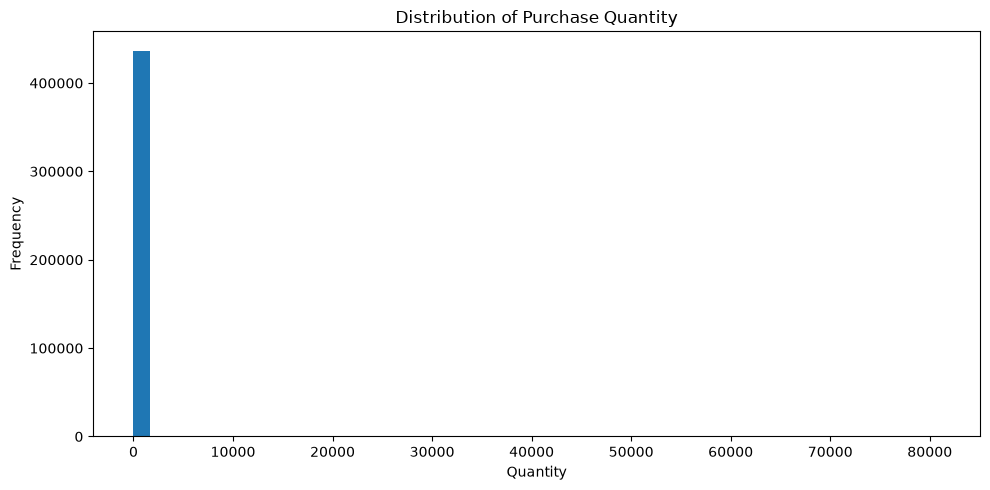

In [57]:
plt.figure(figsize=(10, 5))

plt.hist(purchases["quantity"], bins=50)

plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Purchase Quantity")

plt.tight_layout()
plt.show()

In [61]:
print("Quantity percentiles:")

for p in [0.90, 0.95, 0.99, 0.995, 0.999, 0.9999]:
    print(f"{p * 100:.2f}th percentile:", purchases["quantity"].quantile(p))

Quantity percentiles:
90.00th percentile: 24.0
95.00th percentile: 36.0
99.00th percentile: 120.0
99.50th percentile: 192.0
99.90th percentile: 492.6240000000689
99.99th percentile: 1491.9743999994826


In [62]:
for limit in [50, 100, 500, 1000, 5000, 10000]:
    count = (purchases["quantity"] > limit).sum()
    print(f"Quantity > {limit}: {count} rows")
    

Quantity > 50: 11609 rows
Quantity > 100: 4665 rows
Quantity > 500: 408 rows
Quantity > 1000: 106 rows
Quantity > 5000: 3 rows
Quantity > 10000: 3 rows


In [63]:
top_quantities = (
    purchases
    .sort_values("quantity", ascending=False)
    [["InvoiceID", "date", "CustomerID", "product_id", "quantity"]]
    .head(20)
)

display(top_quantities)

,InvoiceID,date,CustomerID,product_id,quantity
397451,581483,2015-12-09,16446,2414,80995
37126,541431,2015-01-18,12346,2074,74215
370473,578841,2015-11-25,13256,239,12540
308128,573008,2015-10-27,12901,3941,4800
143243,554868,2015-05-27,13135,3393,4300
61586,544612,2015-02-22,18087,1159,3906
188812,560599,2015-07-19,14609,1193,3186
109624,550461,2015-04-18,15749,1198,3114
32732,540815,2015-01-11,15749,1198,3114
318104,573995,2015-11-02,16308,3365,3000


In [64]:
total_quantity = purchases["quantity"].sum()

for limit in [100, 500, 1000, 5000, 10000]:
    quantity_from_extremes = purchases.loc[
        purchases["quantity"] > limit,
        "quantity"
    ].sum()
    
    percentage = (quantity_from_extremes / total_quantity) * 100
    
    print(
        f"Quantity > {limit}: "
        f"{quantity_from_extremes:,} units "
        f"({percentage:.2f}% of total demand)"
    )

Quantity > 100: 1,395,822 units (26.44% of total demand)
Quantity > 500: 544,026 units (10.31% of total demand)
Quantity > 1000: 338,593 units (6.41% of total demand)
Quantity > 5000: 167,750 units (3.18% of total demand)
Quantity > 10000: 167,750 units (3.18% of total demand)


In [65]:
top_3 = (
    purchases
    .nlargest(3, "quantity")
    [["InvoiceID", "date", "CustomerID", "product_id", "quantity"]]
)

display(top_3)

,InvoiceID,date,CustomerID,product_id,quantity
397451,581483,2015-12-09,16446,2414,80995
37126,541431,2015-01-18,12346,2074,74215
370473,578841,2015-11-25,13256,239,12540


In [66]:
top_3_details = (
    purchases
    .nlargest(3, "quantity")
    .merge(
        products[["product_id", "item", "category", "price"]],
        on="product_id",
        how="left"
    )
    .merge(
        customers[["CustomerID", "customer_type"]],
        on="CustomerID",
        how="left"
    )
)

top_3_details["calculated_sales"] = (
    top_3_details["quantity"] * top_3_details["price"]
)

display(top_3_details)

,InvoiceID,date,CustomerID,product_id,quantity,item,category,price,customer_type,calculated_sales
0,581483,2015-12-09,16446,2414,80995,"paper craft , little birdie",Stationery & Craft,2.08,wholesaler,168469.6
1,541431,2015-01-18,12346,2074,74215,medium ceramic top storage jar,Kitchen & Dining,1.04,wholesaler,77183.6
2,578841,2015-11-25,13256,239,12540,asstd design 3d paper stickers,Party & Festive,0.85,wholesaler,10659.0


In [67]:
top_invoice_ids = top_3_details["InvoiceID"].tolist()

top_invoices = purchases[
    purchases["InvoiceID"].isin(top_invoice_ids)
].sort_values(["InvoiceID", "quantity"], ascending=[True, False])

display(top_invoices)

,InvoiceID,date,CustomerID,product_id,quantity
37126,541431,2015-01-18,12346,2074,74215
370473,578841,2015-11-25,13256,239,12540
397451,581483,2015-12-09,16446,2414,80995


In [68]:
customer_type_analysis = (
    purchases
    .groupby("CustomerID")
    .agg(
        total_quantity=("quantity", "sum"),
        total_orders=("InvoiceID", "nunique")
    )
    .reset_index()
    .merge(
        customers[["CustomerID", "customer_type"]],
        on="CustomerID",
        how="left"
    )
)

display(
    customer_type_analysis
    .groupby("customer_type")
    .agg(
        customers=("CustomerID", "nunique"),
        total_quantity=("total_quantity", "sum"),
        avg_quantity_per_customer=("total_quantity", "mean"),
        median_quantity_per_customer=("total_quantity", "median"),
        avg_orders_per_customer=("total_orders", "mean")
    )
    .reset_index()
)

,customer_type,customers,total_quantity,avg_quantity_per_customer,median_quantity_per_customer,avg_orders_per_customer
0,private,7161,1162941,162.399246,41.0,3.148862
1,wholesaler,1076,4115593,3824.900558,1832.0,10.176580


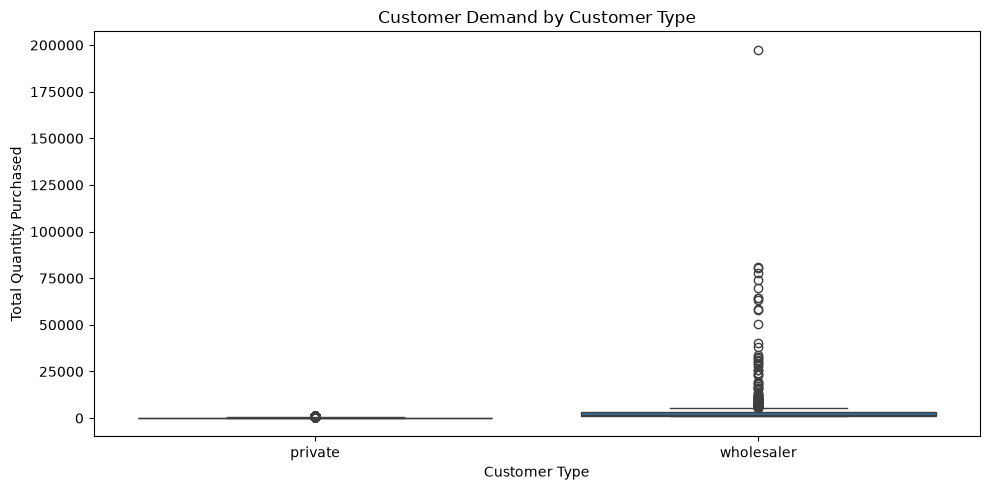

In [69]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=customer_type_analysis,
    x="customer_type",
    y="total_quantity"
)

plt.xlabel("Customer Type")
plt.ylabel("Total Quantity Purchased")
plt.title("Customer Demand by Customer Type")

plt.tight_layout()
plt.show()

In [70]:
monthly_customer_type = (
    purchases
    .merge(
        customers[["CustomerID", "customer_type"]],
        on="CustomerID",
        how="left"
    )
    .groupby([
        purchases["date"].dt.to_period("M"),
        "customer_type"
    ])["quantity"]
    .sum()
    .reset_index()
)

monthly_customer_type.columns = [
    "month",
    "customer_type",
    "quantity"
]

display(monthly_customer_type)

,month,customer_type,quantity
0,2014-01,private,3794
1,2014-02,private,3533
2,2014-03,private,3557
3,2014-04,private,3859
4,2014-05,private,4073
5,2014-06,private,3947
6,2014-07,private,3900
7,2014-08,private,3882
8,2014-09,private,3668
9,2014-10,private,3889


In [72]:
plot_data = monthly_customer_type.copy()

plot_data["month"] = plot_data["month"].astype(str)

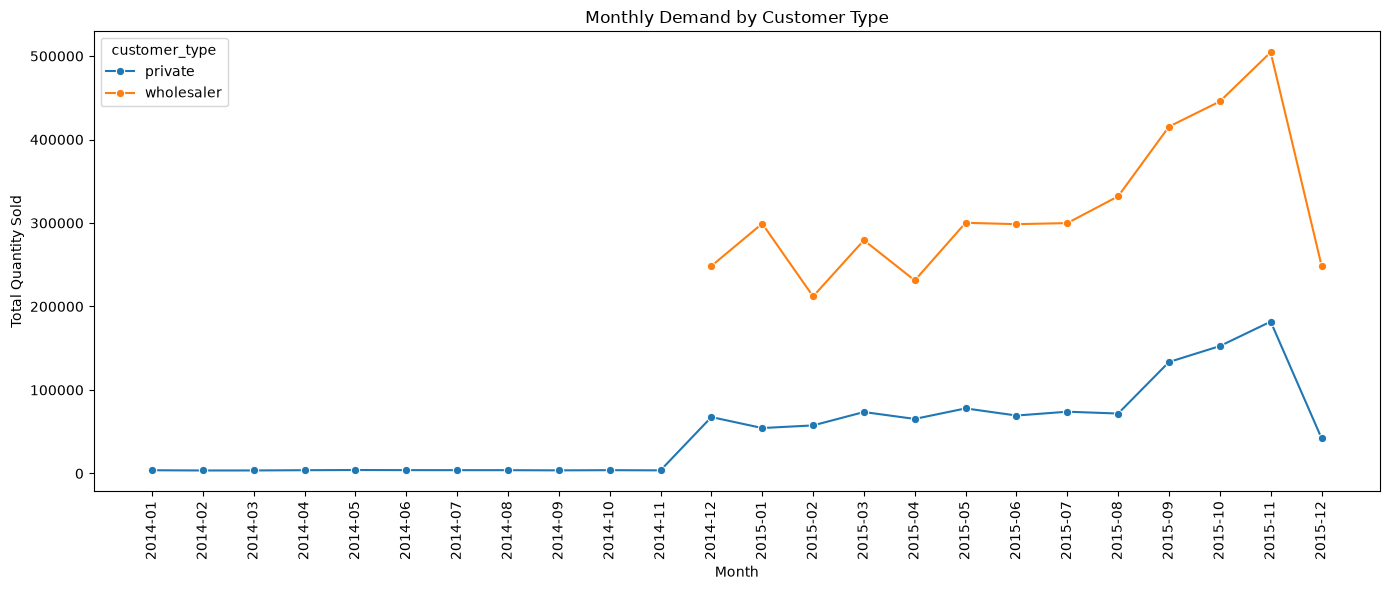

In [73]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=plot_data,
    x="month",
    y="quantity",
    hue="customer_type",
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.title("Monthly Demand by Customer Type")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [74]:
monthly_activity = (
    purchases
    .groupby(purchases["date"].dt.to_period("M"))
    .agg(
        unique_customers=("CustomerID", "nunique"),
        unique_invoices=("InvoiceID", "nunique"),
        purchase_rows=("InvoiceID", "size"),
        total_quantity=("quantity", "sum")
    )
    .reset_index()
)

monthly_activity.columns = [
    "month",
    "unique_customers",
    "unique_invoices",
    "purchase_rows",
    "total_quantity"
]

display(monthly_activity)

,month,unique_customers,unique_invoices,purchase_rows,total_quantity
0,2014-01,612,665,1527,3794
1,2014-02,589,623,1437,3533
2,2014-03,573,608,1411,3557
3,2014-04,632,678,1561,3859
4,2014-05,660,711,1615,4073
5,2014-06,613,674,1570,3947
6,2014-07,628,680,1576,3900
7,2014-08,637,690,1575,3882
8,2014-09,602,651,1472,3668
9,2014-10,639,697,1591,3889


In [75]:
monthly_activity["rows_per_invoice"] = (
    monthly_activity["purchase_rows"] /
    monthly_activity["unique_invoices"]
)

monthly_activity["quantity_per_invoice"] = (
    monthly_activity["total_quantity"] /
    monthly_activity["unique_invoices"]
)

display(monthly_activity)

,month,unique_customers,unique_invoices,purchase_rows,total_quantity,rows_per_invoice,quantity_per_invoice
0,2014-01,612,665,1527,3794,2.296241,5.705263
1,2014-02,589,623,1437,3533,2.306581,5.670947
2,2014-03,573,608,1411,3557,2.320724,5.850329
3,2014-04,632,678,1561,3859,2.302360,5.691740
4,2014-05,660,711,1615,4073,2.271449,5.728551
5,2014-06,613,674,1570,3947,2.329377,5.856083
6,2014-07,628,680,1576,3900,2.317647,5.735294
7,2014-08,637,690,1575,3882,2.282609,5.626087
8,2014-09,602,651,1472,3668,2.261137,5.634409
9,2014-10,639,697,1591,3889,2.282640,5.579627


In [76]:
invoice_demand = (
    purchases
    .groupby(["InvoiceID", "date"])
    .agg(
        invoice_quantity=("quantity", "sum"),
        number_of_items=("product_id", "count")
    )
    .reset_index()
)

invoice_demand["period"] = np.where(
    invoice_demand["date"] < pd.Timestamp("2014-12-01"),
    "Before Dec 2014",
    "Dec 2014 onwards"
)

display(
    invoice_demand
    .groupby("period")
    .agg(
        invoices=("InvoiceID", "count"),
        avg_invoice_quantity=("invoice_quantity", "mean"),
        median_invoice_quantity=("invoice_quantity", "median"),
        max_invoice_quantity=("invoice_quantity", "max"),
        avg_items_per_invoice=("number_of_items", "mean"),
        median_items_per_invoice=("number_of_items", "median")
    )
    .reset_index()
)

,period,invoices,avg_invoice_quantity,median_invoice_quantity,max_invoice_quantity,avg_items_per_invoice,median_items_per_invoice
0,Before Dec 2014,7324,5.703987,5.0,20,2.294375,2.0
1,Dec 2014 onwards,26175,200.067163,87.0,80995,16.041452,8.0


In [77]:
for period, group in invoice_demand.groupby("period"):

    print(f"\n{period}")
    
    print(
        group["invoice_quantity"].quantile(
            [0.50, 0.75, 0.90, 0.95, 0.99]
        )
    )


Before Dec 2014
0.50     5.0
0.75     7.0
0.90     8.0
0.95    10.0
0.99    12.0
Name: invoice_quantity, dtype: float64

Dec 2014 onwards
0.50      87.00
0.75     222.00
0.90     422.00
0.95     626.30
0.99    1787.26
Name: invoice_quantity, dtype: float64


In [78]:
repeated_invoice_product = (
    purchases
    .groupby(["InvoiceID", "product_id"])
    .agg(
        row_count=("quantity", "size"),
        total_quantity=("quantity", "sum"),
        quantities=("quantity", list)
    )
    .reset_index()
)

repeated_invoice_product = repeated_invoice_product[
    repeated_invoice_product["row_count"] > 1
]

print("Repeated InvoiceID + product_id groups:",
      len(repeated_invoice_product))


display(repeated_invoice_product.head(20))

Repeated InvoiceID + product_id groups: 10007


,InvoiceID,product_id,row_count,total_quantity,quantities
39,18,2956,2,5,"[2, 3]"
61,27,2956,2,5,"[4, 1]"
75,32,1341,2,4,"[1, 3]"
88,34,4004,2,7,"[3, 4]"
267,103,2961,2,2,"[1, 1]"
296,115,2304,2,7,"[3, 4]"
346,133,4004,2,7,"[4, 3]"
426,163,4004,2,5,"[1, 4]"
485,187,3280,2,3,"[1, 2]"
492,190,4004,2,3,"[2, 1]"


In [79]:
repeated_invoice_product["same_quantity"] = (
    repeated_invoice_product["quantities"]
    .apply(lambda x: len(set(x)) == 1)
)

print(
    repeated_invoice_product["same_quantity"]
    .value_counts()
)

same_quantity
False    5292
True     4715
Name: count, dtype: int64


In [80]:
# Total quantity from repeated InvoiceID + product_id groups
repeated_quantity = repeated_invoice_product["total_quantity"].sum()

# Number of rows belonging to repeated groups
repeated_rows = repeated_invoice_product["row_count"].sum()

# Compare with the complete dataset
total_quantity = purchases["quantity"].sum()
total_rows = len(purchases)

print("Repeated InvoiceID + product_id groups:", len(repeated_invoice_product))
print("Rows belonging to repeated groups:", repeated_rows)
print("Quantity from repeated groups:", repeated_quantity)

print("\nPercentage of rows:",
      round(repeated_rows / total_rows * 100, 2), "%")

print("Percentage of quantity:",
      round(repeated_quantity / total_quantity * 100, 2), "%")

Repeated InvoiceID + product_id groups: 10007
Rows belonging to repeated groups: 20995
Quantity from repeated groups: 78497

Percentage of rows: 4.81 %
Percentage of quantity: 1.49 %


In [81]:
same_quantity_groups = repeated_invoice_product[
    repeated_invoice_product["same_quantity"]
]

different_quantity_groups = repeated_invoice_product[
    ~repeated_invoice_product["same_quantity"]
]

print("Same-quantity repeated groups:",
      len(same_quantity_groups))

print("Quantity from same-quantity groups:",
      same_quantity_groups["total_quantity"].sum())

print("\nDifferent-quantity repeated groups:",
      len(different_quantity_groups))

print("Quantity from different-quantity groups:",
      different_quantity_groups["total_quantity"].sum())

Same-quantity repeated groups: 4715
Quantity from same-quantity groups: 31730

Different-quantity repeated groups: 5292
Quantity from different-quantity groups: 46767


In [82]:
daily_pattern = (
    purchases
    .assign(day_of_week=purchases["date"].dt.day_name())
    .groupby("day_of_week")
    .agg(
        total_quantity=("quantity", "sum"),
        avg_daily_quantity=("quantity", "mean"),
        purchase_rows=("quantity", "size"),
        unique_invoices=("InvoiceID", "nunique")
    )
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
    .reset_index()
)

display(daily_pattern)

,day_of_week,total_quantity,avg_daily_quantity,purchase_rows,unique_invoices
0,Monday,975946,13.140514,74270,5522
1,Tuesday,1166368,13.624203,85610,6175
2,Wednesday,837313,13.863716,60396,4962
3,Thursday,14101,2.509075,5620,2188
4,Friday,480377,7.029530,68337,4305
5,Saturday,782737,11.110532,70450,5024
6,Sunday,1021692,14.188984,72006,5323


In [83]:
weekday_daily = (
    purchases
    .assign(day_of_week=purchases["date"].dt.day_name())
    .groupby(["date", "day_of_week"])["quantity"]
    .sum()
    .reset_index()
)

weekday_summary = (
    weekday_daily
    .groupby("day_of_week")["quantity"]
    .agg(
        avg_quantity="mean",
        median_quantity="median",
        max_quantity="max"
    )
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
    .reset_index()
)

display(weekday_summary)

,day_of_week,avg_quantity,median_quantity,max_quantity
0,Monday,9384.096154,4731.5,46048
1,Tuesday,11215.076923,5834.0,41002
2,Wednesday,8051.086538,174.0,90686
3,Thursday,135.586538,134.0,234
4,Friday,4619.009615,187.5,23473
5,Saturday,7526.317308,169.5,38546
6,Sunday,9823.961538,2272.0,80775


In [84]:
weekday_dates = (
    purchases[["date"]]
    .drop_duplicates()
    .assign(
        day_of_week=lambda x: x["date"].dt.day_name()
    )
    .groupby("day_of_week")
    .agg(
        number_of_dates=("date", "count"),
        first_date=("date", "min"),
        last_date=("date", "max")
    )
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
    .reset_index()
)

display(weekday_dates)

,day_of_week,number_of_dates,first_date,last_date
0,Monday,104,2014-01-06,2015-12-28
1,Tuesday,104,2014-01-07,2015-12-29
2,Wednesday,104,2014-01-01,2015-12-30
3,Thursday,104,2014-01-02,2015-12-24
4,Friday,104,2014-01-03,2015-12-25
5,Saturday,104,2014-01-04,2015-12-26
6,Sunday,104,2014-01-05,2015-12-27


In [85]:
weekday_period = (
    purchases
    .assign(
        day_of_week=purchases["date"].dt.day_name(),
        period=np.where(
            purchases["date"] < pd.Timestamp("2014-12-01"),
            "Before Dec 2014",
            "Dec 2014 onwards"
        )
    )
    .groupby(["period", "day_of_week"])
    .agg(
        purchase_rows=("quantity", "size"),
        total_quantity=("quantity", "sum"),
        unique_dates=("date", "nunique")
    )
    .reset_index()
)

display(weekday_period)

,period,day_of_week,purchase_rows,total_quantity,unique_dates
0,Before Dec 2014,Friday,2347,5878,48
1,Before Dec 2014,Monday,2377,5920,47
2,Before Dec 2014,Saturday,2478,6096,48
3,Before Dec 2014,Sunday,2378,5961,48
4,Before Dec 2014,Thursday,2533,6308,48
5,Before Dec 2014,Tuesday,2384,5910,47
6,Before Dec 2014,Wednesday,2307,5703,48
7,Dec 2014 onwards,Friday,65990,474499,56
8,Dec 2014 onwards,Monday,71893,970026,57
9,Dec 2014 onwards,Saturday,67972,776641,56


In [86]:
weekday_robust = (
    purchases
    .groupby("date")["quantity"]
    .sum()
    .reset_index(name="daily_quantity")
)

weekday_robust["day_of_week"] = (
    weekday_robust["date"].dt.day_name()
)

weekday_robust_summary = (
    weekday_robust
    .groupby("day_of_week")["daily_quantity"]
    .agg(
        mean="mean",
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        max="max"
    )
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
    .reset_index()
)

display(weekday_robust_summary)

,day_of_week,mean,median,q25,q75,max
0,Monday,9384.096154,4731.5,124.00,17565.00,46048
1,Tuesday,11215.076923,5834.0,126.75,19161.25,41002
2,Wednesday,8051.086538,174.0,129.75,13161.25,90686
3,Thursday,135.586538,134.0,111.75,159.25,234
4,Friday,4619.009615,187.5,118.50,7835.25,23473
5,Saturday,7526.317308,169.5,120.50,13377.50,38546
6,Sunday,9823.961538,2272.0,123.75,16087.25,80775


In [87]:
weekday_period_robust = (
    purchases
    .groupby("date")["quantity"]
    .sum()
    .reset_index(name="daily_quantity")
)

weekday_period_robust["day_of_week"] = (
    weekday_period_robust["date"].dt.day_name()
)

weekday_period_robust["period"] = np.where(
    weekday_period_robust["date"] < pd.Timestamp("2014-12-01"),
    "Before Dec 2014",
    "Dec 2014 onwards"
)

display(
    weekday_period_robust
    .groupby(["period", "day_of_week"])["daily_quantity"]
    .agg(
        mean="mean",
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
    .reindex(
        [
            ("Before Dec 2014", "Monday"),
            ("Before Dec 2014", "Tuesday"),
            ("Before Dec 2014", "Wednesday"),
            ("Before Dec 2014", "Thursday"),
            ("Before Dec 2014", "Friday"),
            ("Before Dec 2014", "Saturday"),
            ("Before Dec 2014", "Sunday"),
            ("Dec 2014 onwards", "Monday"),
            ("Dec 2014 onwards", "Tuesday"),
            ("Dec 2014 onwards", "Wednesday"),
            ("Dec 2014 onwards", "Thursday"),
            ("Dec 2014 onwards", "Friday"),
            ("Dec 2014 onwards", "Saturday"),
            ("Dec 2014 onwards", "Sunday")
        ]
    )
    .reset_index()
)

,period,day_of_week,mean,median,q25,q75
0,Before Dec 2014,Monday,125.957447,123.0,101.00,142.00
1,Before Dec 2014,Tuesday,125.744681,123.0,110.50,143.00
2,Before Dec 2014,Wednesday,118.812500,123.5,95.00,139.00
3,Before Dec 2014,Thursday,131.416667,129.0,110.50,149.50
4,Before Dec 2014,Friday,122.458333,118.0,101.25,144.00
5,Before Dec 2014,Saturday,127.000000,125.0,106.75,145.00
6,Before Dec 2014,Sunday,124.187500,123.5,108.25,139.75
7,Dec 2014 onwards,Monday,17018.000000,16347.0,11664.00,20284.00
8,Dec 2014 onwards,Tuesday,20358.912281,18393.0,13837.00,27913.00
9,Dec 2014 onwards,Wednesday,14850.178571,12695.5,9636.75,17712.25


In [91]:
transition_daily = (
    purchases
    .groupby("date")["quantity"]
    .sum()
    .reset_index()
)

transition_daily = transition_daily[
    (transition_daily["date"] >= "2014-11-01") &
    (transition_daily["date"] <= "2015-01-31")
]

display(transition_daily.to_string(index=False))

'      date  quantity\n2014-11-01        84\n2014-11-02       126\n2014-11-03       122\n2014-11-04       100\n2014-11-05       183\n2014-11-06        70\n2014-11-07       167\n2014-11-08       116\n2014-11-09       124\n2014-11-10       187\n2014-11-11       113\n2014-11-12        97\n2014-11-13       146\n2014-11-14       144\n2014-11-15       124\n2014-11-16        89\n2014-11-17       106\n2014-11-18       110\n2014-11-19       106\n2014-11-20       145\n2014-11-21       111\n2014-11-22       170\n2014-11-23        81\n2014-11-24       129\n2014-11-25       104\n2014-11-26       134\n2014-11-27       136\n2014-11-28       112\n2014-11-29       113\n2014-11-30       125\n2014-12-01     24325\n2014-12-02     31269\n2014-12-03     11997\n2014-12-04        79\n2014-12-05     16543\n2014-12-06     16425\n2014-12-07     19520\n2014-12-08     21677\n2014-12-09     17505\n2014-12-10     16199\n2014-12-11       148\n2014-12-12     10735\n2014-12-13     15482\n2014-12-14     17883\n2014-12-1

In [90]:
transition_daily = (
    purchases
    .groupby("date")["quantity"]
    .sum()
    .reset_index()
)

transition_daily = transition_daily[
    (transition_daily["date"] >= "2014-11-01") &
    (transition_daily["date"] <= "2015-01-31")
]

display(transition_daily)

,date,quantity
304,2014-11-01,84
305,2014-11-02,126
306,2014-11-03,122
307,2014-11-04,100
308,2014-11-05,183
...,...,...
390,2015-01-27,11122
391,2015-01-28,9353
392,2015-01-29,107
393,2015-01-30,3513


In [92]:
weekday_activity = (
    purchases
    .assign(day_of_week=purchases["date"].dt.day_name())
    .groupby("day_of_week")
    .agg(
        purchase_rows=("quantity", "size"),
        total_quantity=("quantity", "sum"),
        unique_invoices=("InvoiceID", "nunique"),
        unique_customers=("CustomerID", "nunique")
    )
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
    .reset_index()
)

weekday_activity["quantity_per_row"] = (
    weekday_activity["total_quantity"]
    / weekday_activity["purchase_rows"]
)

weekday_activity["rows_per_invoice"] = (
    weekday_activity["purchase_rows"]
    / weekday_activity["unique_invoices"]
)

display(weekday_activity)

,day_of_week,purchase_rows,total_quantity,unique_invoices,unique_customers,quantity_per_row,rows_per_invoice
0,Monday,74270,975946,5522,3403,13.140514,13.449837
1,Tuesday,85610,1166368,6175,3670,13.624203,13.863968
2,Wednesday,60396,837313,4962,3192,13.863716,12.171705
3,Thursday,5620,14101,2188,1682,2.509075,2.568556
4,Friday,68337,480377,4305,2854,7.029530,15.873868
5,Saturday,70450,782737,5024,3275,11.110532,14.022691
6,Sunday,72006,1021692,5323,3348,14.188984,13.527334


In [93]:
thursday_check = (
    purchases.assign(
        day_of_week=purchases["date"].dt.day_name(),
        period=np.where(
            purchases["date"] < pd.Timestamp("2014-12-01"),
            "Before Dec 2014",
            "Dec 2014 onwards"
        )
    )
    .query("day_of_week == 'Thursday'")
    .groupby("period")
    .agg(
        purchase_rows=("quantity", "size"),
        total_quantity=("quantity", "sum"),
        unique_invoices=("InvoiceID", "nunique"),
        unique_customers=("CustomerID", "nunique")
    )
    .reset_index()
)

thursday_check["quantity_per_row"] = (
    thursday_check["total_quantity"]
    / thursday_check["purchase_rows"]
)

display(thursday_check)

,period,purchase_rows,total_quantity,unique_invoices,unique_customers,quantity_per_row
0,Before Dec 2014,2533,6308,1117,971,2.490328
1,Dec 2014 onwards,3087,7793,1071,937,2.524457


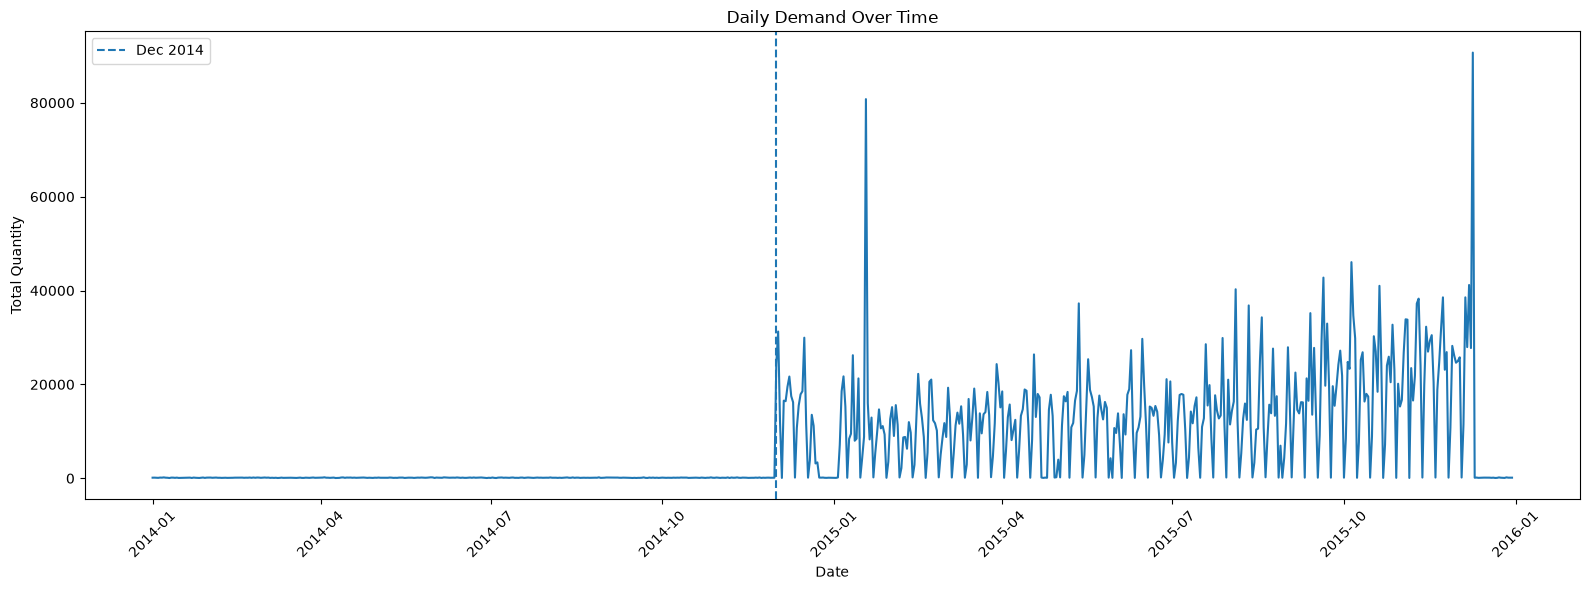

In [94]:
daily_demand = (
    purchases
    .groupby("date")["quantity"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(16, 6))

plt.plot(
    daily_demand["date"],
    daily_demand["quantity"]
)

plt.axvline(
    pd.Timestamp("2014-12-01"),
    linestyle="--",
    label="Dec 2014"
)

plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Quantity")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

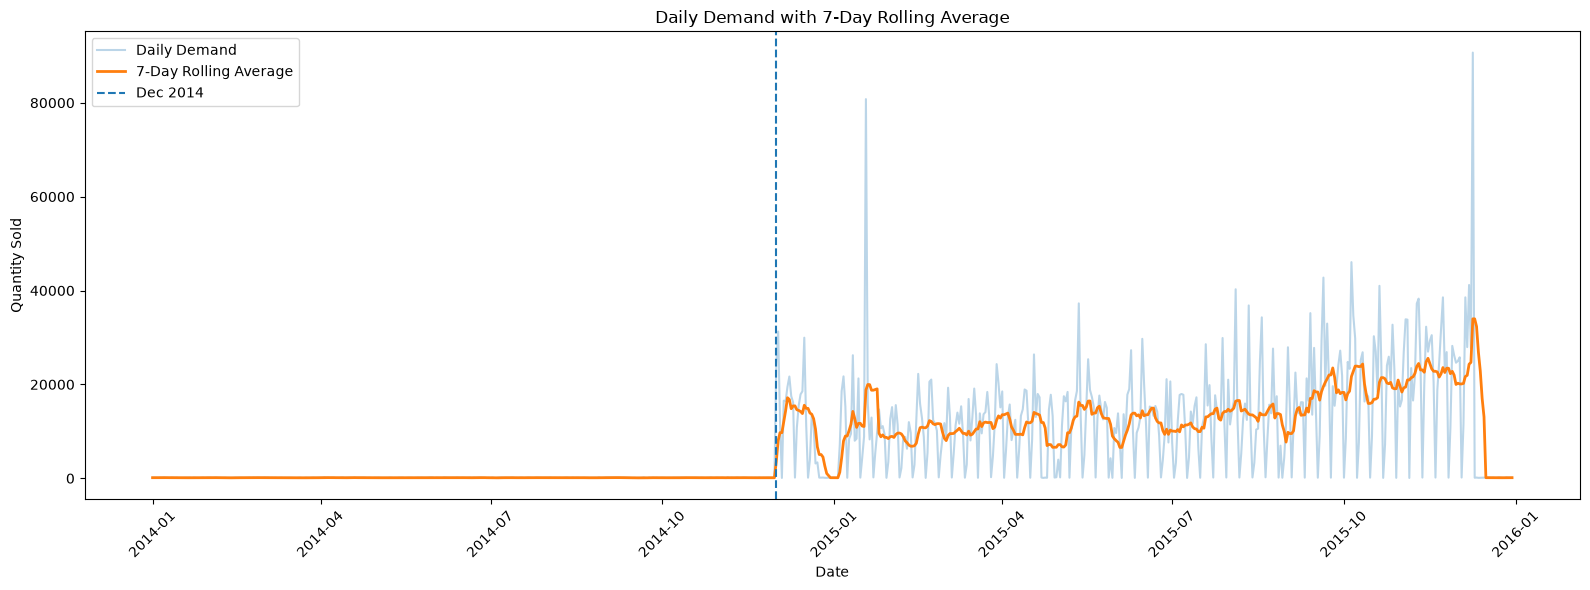

In [95]:
daily_trend = (
    purchases
    .groupby("date")["quantity"]
    .sum()
    .sort_index()
    .to_frame(name="daily_quantity")
)

daily_trend["rolling_7d"] = (
    daily_trend["daily_quantity"]
    .rolling("7D")
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    daily_trend.index,
    daily_trend["daily_quantity"],
    alpha=0.3,
    label="Daily Demand"
)

plt.plot(
    daily_trend.index,
    daily_trend["rolling_7d"],
    linewidth=2,
    label="7-Day Rolling Average"
)

plt.axvline(
    pd.Timestamp("2014-12-01"),
    linestyle="--",
    label="Dec 2014"
)

plt.title("Daily Demand with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [98]:
purchases.columns.tolist()

['InvoiceID', 'date', 'CustomerID', 'product_id', 'quantity']

In [105]:
top_products = (
    purchases.groupby("product_id")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top_products

product_id
2414    80995
2074    77916
3941    54415
1828    46181
3851    36725
209     35362
2363    33693
2699    30931
2762    27202
2129    26076
2329    25345
2361    24264
543     22963
3682    22433
217     21876
2787    20975
1826    20165
3393    18252
2018    17697
100     17689
Name: quantity, dtype: int64

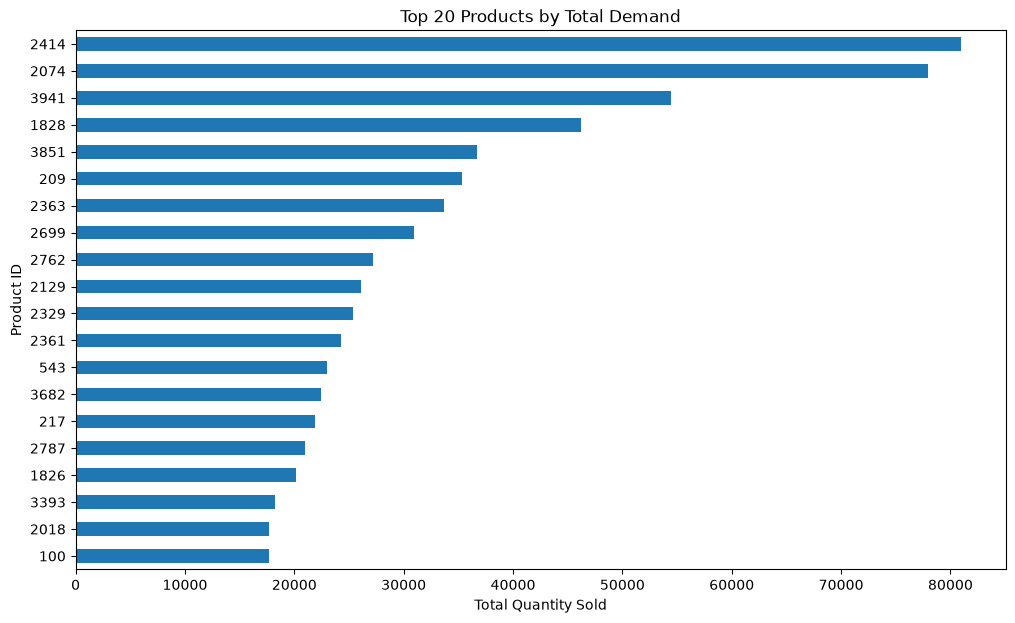

In [100]:
plt.figure(figsize=(12, 7))

top_products.sort_values().plot(kind="barh")

plt.title("Top 20 Products by Total Demand")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product ID")

plt.show()

In [101]:
product_demand = (
    purchases.groupby("product_id")["quantity"]
    .agg(
        total_quantity="sum",
        avg_quantity="mean",
        median_quantity="median",
        purchase_rows="count"
    )
    .sort_values("total_quantity", ascending=False)
)

product_demand.head(20)

,total_quantity,avg_quantity,median_quantity,purchase_rows
product_id,,,,
2414,80995,80995.000000,80995.0,1
2074,77916,393.515152,12.0,198
3941,54415,115.042283,48.0,473
1828,46181,28.542027,10.0,1618
3851,36725,18.108974,6.0,2028
209,35362,25.115057,16.0,1408
2363,33693,31.547753,24.0,1068
2699,30931,47.079148,12.0,657
2762,27202,32.306413,7.0,842


In [102]:
total_demand = purchases["quantity"].sum()

top_10_demand = product_demand.head(10)["total_quantity"].sum()
top_20_demand = product_demand.head(20)["total_quantity"].sum()
top_50_demand = product_demand.head(50)["total_quantity"].sum()

print("Total demand:", total_demand)

print("Top 10 demand:", top_10_demand)
print("Top 10 share:", round(top_10_demand / total_demand * 100, 2), "%")

print("Top 20 demand:", top_20_demand)
print("Top 20 share:", round(top_20_demand / total_demand * 100, 2), "%")

print("Top 50 demand:", top_50_demand)
print("Top 50 share:", round(top_50_demand / total_demand * 100, 2), "%")

Total demand: 5278534
Top 10 demand: 449496
Top 10 share: 8.52 %
Top 20 demand: 661155
Top 20 share: 12.53 %
Top 50 demand: 1071195
Top 50 share: 20.29 %


In [106]:
product_stats = (
    purchases.groupby("product_id")["quantity"]
    .agg(
        total_quantity="sum",
        purchase_rows="count"
    )
)

product_stats.describe()

,total_quantity,purchase_rows
count,4033.000000,4033.000000
mean,1308.835606,108.278949
std,3308.040969,173.658000
min,1.000000,1.000000
25%,57.000000,11.000000
50%,338.000000,46.000000
75%,1296.000000,132.000000
max,80995.000000,2502.000000


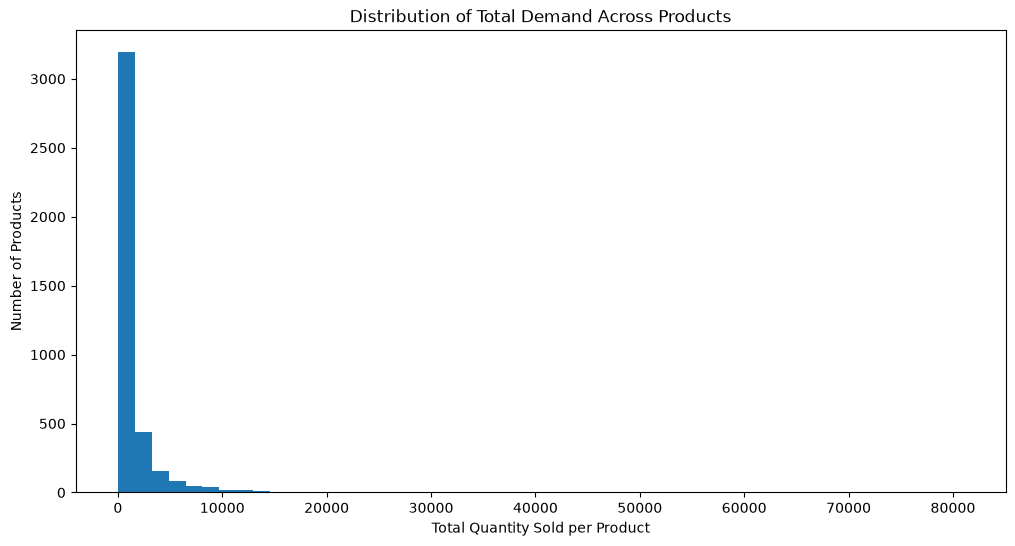

In [107]:
plt.figure(figsize=(12, 6))

plt.hist(product_stats["total_quantity"], bins=50)

plt.title("Distribution of Total Demand Across Products")
plt.xlabel("Total Quantity Sold per Product")
plt.ylabel("Number of Products")

plt.show()

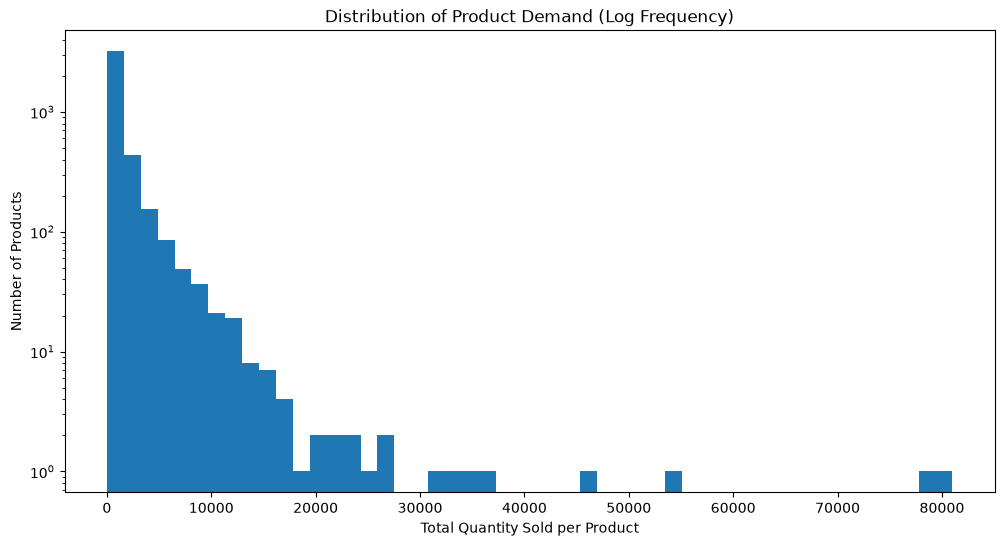

In [108]:
plt.figure(figsize=(12, 6))

plt.hist(product_stats["total_quantity"], bins=50, log=True)

plt.title("Distribution of Product Demand (Log Frequency)")
plt.xlabel("Total Quantity Sold per Product")
plt.ylabel("Number of Products")

plt.show()

In [109]:
print("Number of products:", len(product_stats))

print("\nProducts with total demand < 100:")
print((product_stats["total_quantity"] < 100).sum())

print("\nProducts with total demand 100-1000:")
print(((product_stats["total_quantity"] >= 100) &
       (product_stats["total_quantity"] < 1000)).sum())

print("\nProducts with total demand 1000-10000:")
print(((product_stats["total_quantity"] >= 1000) &
       (product_stats["total_quantity"] < 10000)).sum())

print("\nProducts with total demand >= 10000:")
print((product_stats["total_quantity"] >= 10000).sum())

Number of products: 4033

Products with total demand < 100:
1277

Products with total demand 100-1000:
1537

Products with total demand 1000-10000:
1145

Products with total demand >= 10000:
74


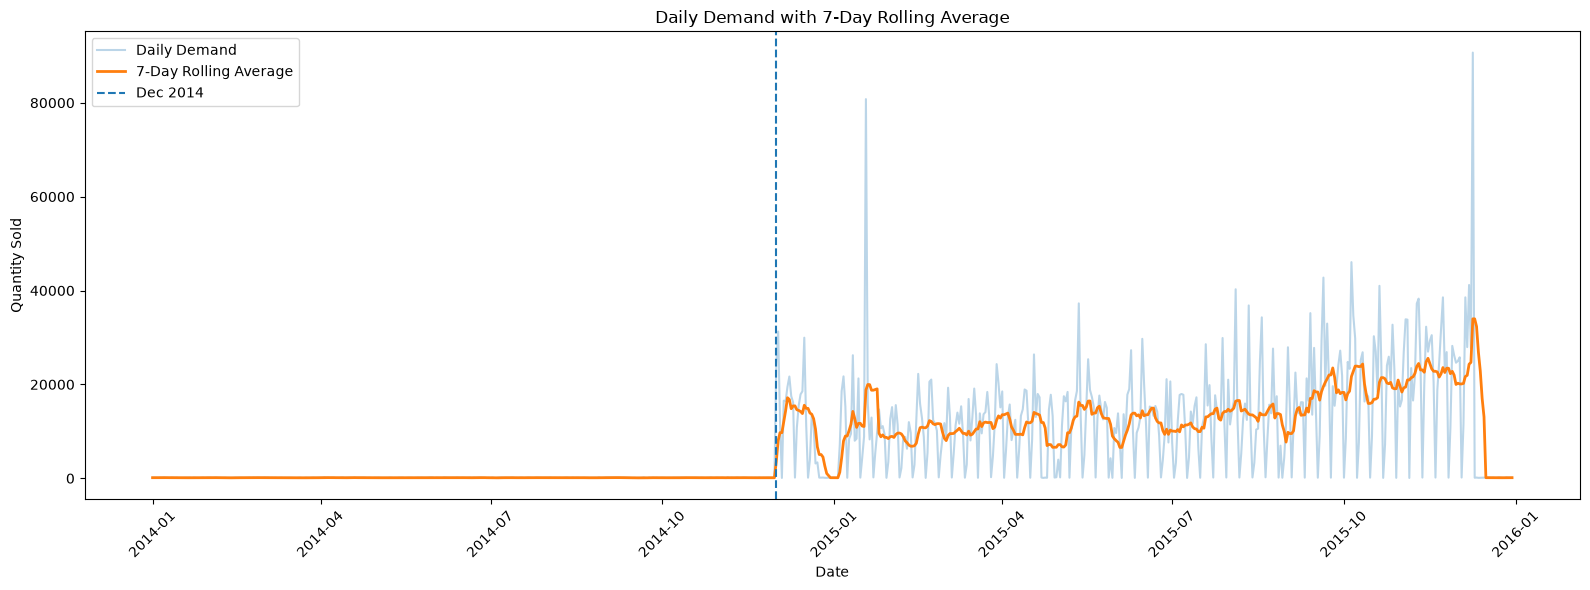

In [110]:
daily_trend = (
    purchases
    .groupby("date")["quantity"]
    .sum()
    .sort_index()
    .to_frame(name="daily_quantity")
)

daily_trend["rolling_7d"] = (
    daily_trend["daily_quantity"]
    .rolling("7D")
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    daily_trend.index,
    daily_trend["daily_quantity"],
    alpha=0.3,
    label="Daily Demand"
)

plt.plot(
    daily_trend.index,
    daily_trend["rolling_7d"],
    linewidth=2,
    label="7-Day Rolling Average"
)

plt.axvline(
    pd.Timestamp("2014-12-01"),
    linestyle="--",
    label="Dec 2014"
)

plt.title("Daily Demand with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [111]:
daily_lag = daily_trend["daily_quantity"]

print("Lag 1 correlation:", daily_lag.autocorr(lag=1))
print("Lag 7 correlation:", daily_lag.autocorr(lag=7))
print("Lag 14 correlation:", daily_lag.autocorr(lag=14))
print("Lag 30 correlation:", daily_lag.autocorr(lag=30))

Lag 1 correlation: 0.604463012654633
Lag 7 correlation: 0.7040561133337279
Lag 14 correlation: 0.6278958120008202
Lag 30 correlation: 0.3525467868837397


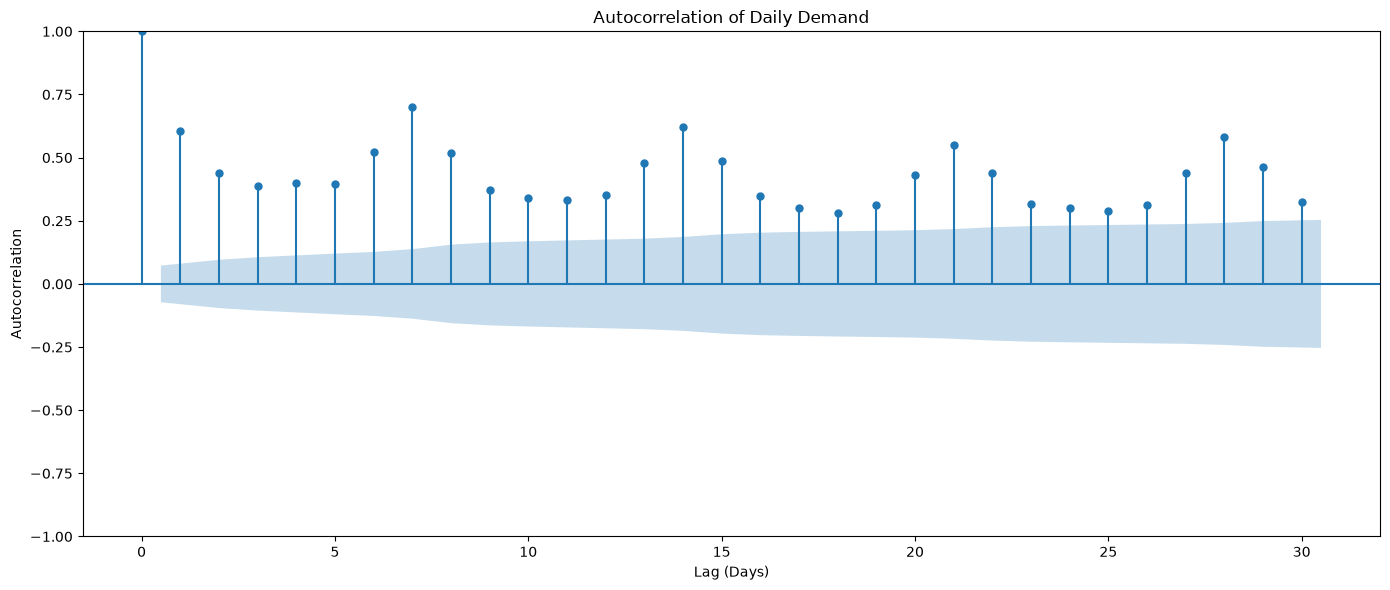

In [112]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(14, 6))

plot_acf(
    daily_lag,
    lags=30,
    ax=plt.gca()
)

plt.title("Autocorrelation of Daily Demand")
plt.xlabel("Lag (Days)")
plt.ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

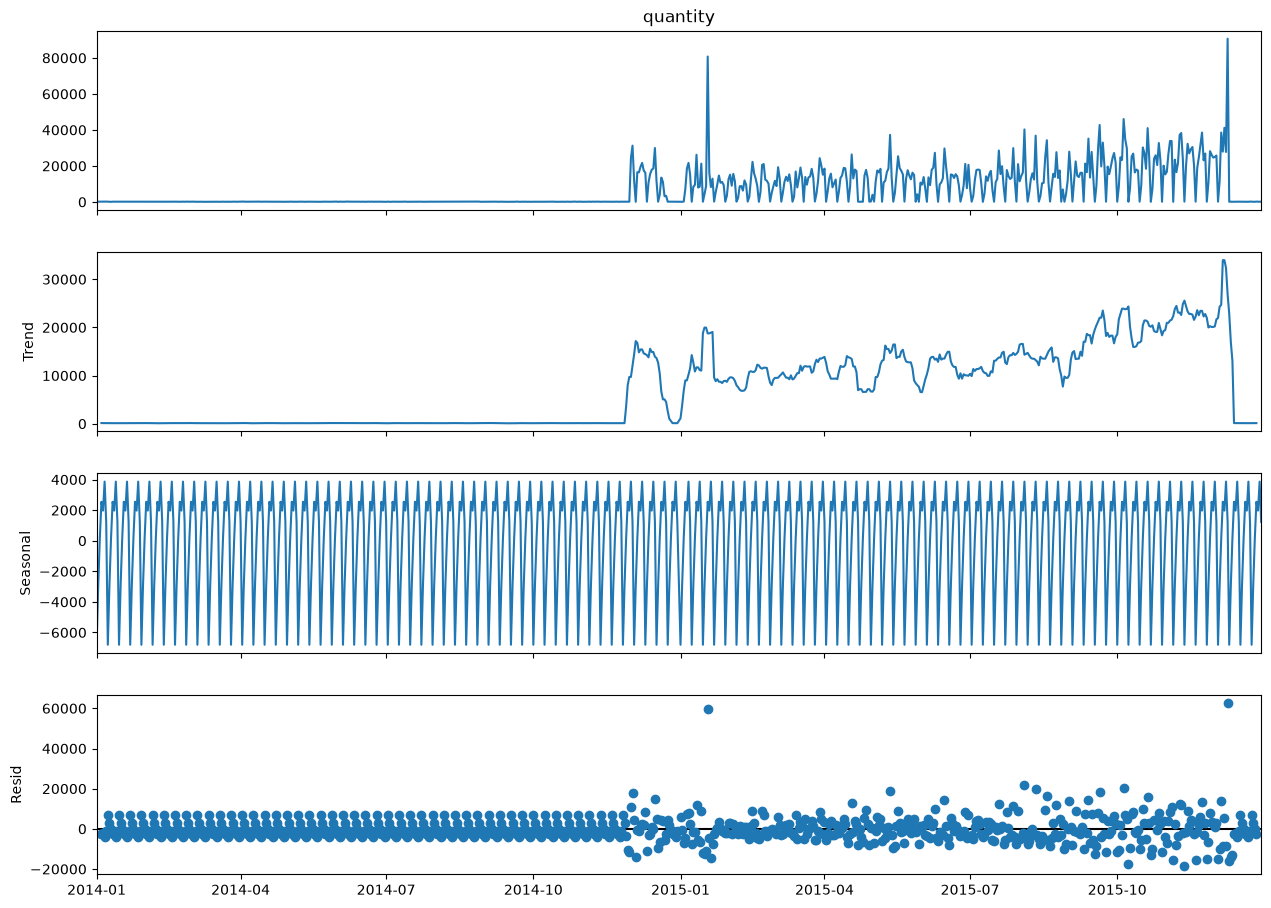

In [115]:
from statsmodels.tsa.seasonal import seasonal_decompose

daily_demand = daily_demand.sort_index()

decomposition = seasonal_decompose(
    daily_demand["quantity"],
    model="additive",
    period=7
)

fig = decomposition.plot()
fig.set_size_inches(14, 10)

plt.show()